In [1]:
import os
import sys
import numpy as np

import torch
import zuko
    
from geobed.utils.sample_distribution import SampleDistribution
from geobed import BED_base_explicit, BED_base_nuisance

if 'PATH_SET' not in locals():
    os.chdir('..')
    PATH_SET = True
    os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'

    os.environ['OMP_NUM_THREADS'] = '1'
    os.environ['MKL_NUM_THREADS'] = '1'

    torch.set_num_threads(1)
    torch.set_num_interop_threads(1)

from helpers.geographic_setup import (
    design_space_full,
)    

from helpers.likelihood import (
    logistic_picking_likelihood_tt, DataLikelihoodAttenuation
    )
from helpers.forward import TTLookup

from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import matplotlib.style as style
style.use('https://raw.githubusercontent.com/dominik-strutz/dotfiles/main/mystyle.mplstyle')

n_workers = 1 # or lower, depending on the task

In [2]:
design_space = design_space_full

model_prior_samples = torch.load('data/priors/prior_samples_full_disp.pt')
model_prior_sample_dist = SampleDistribution(model_prior_samples)

forward_function = TTLookup(
    model_prior_samples, design_space_full,
    torch.load('data/data_lookup/gradient_full_disp.pt'),)


In [3]:
picking_likelihood = logistic_picking_likelihood_tt(
    b = 0.35, c = -30.0
)
data_likelihood = DataLikelihoodAttenuation(
    forward_function=forward_function,
    picking_likelihood=picking_likelihood,
    dependence_distance=100.0,
    # dependence_distance=0.0,
    vel_sigma=0.05,
    tt_obs_std=0.01, 
)

nuisance_dist = zuko.distributions.BoxUniform(
        lower=torch.tensor([0.0,]),
        upper=torch.tensor([1.0,]),
    ) 

BED_class = BED_base_nuisance(
    data_likelihood_func=data_likelihood,
    m_prior_dist=model_prior_sample_dist,
    nuisance_dist=nuisance_dist,
)

# N_scenarios = torch.logspace(1, 4, 10, dtype=torch.int)
N_scenarios = [100, 200, 500, 1000, 2000, 5000, 10000]

M_prime_scenarios = [10, 20, 50, 100]

N_designs = 100
N_rec = 5

torch.manual_seed(0)
designs = torch.stack([
    design_space[
        torch.randperm(len(design_space))[:N_rec]] 
    for _ in range(N_designs)])

In [ ]:
EIG_dict = {}
info_dict = {}

for N in N_scenarios:
    N = N.item() if isinstance(N, torch.Tensor) else N
    for M_prime in M_prime_scenarios:
        
        print(f'Calculating EIG for N = {N} and M_prime = {M_prime}')
        
        eig, info = BED_class.calculate_EIG(
            designs,
            eig_method='NMC',
            eig_method_kwargs=dict(
                N = N,
                M_prime = M_prime,
                reuse_M = True,
                memory_efficient = True,),
            num_workers=n_workers,
            random_seed=1   ,
            progress_bar=True,
            parallel_library='mpire',
            filename=f'convergence_analysis/data/EIG_NMC_attenuation_{N}_M_{M_prime}.pt',
            )
            
        EIG_dict[(N, M_prime)] = eig
        info_dict[(N, M_prime)] = info

Calculating EIG for N = 100 and M_prime = 10


Calculating eig:   0%|          | 0/100 [00:00<?, ?it/s]

Calculating EIG for N = 100 and M_prime = 20


Calculating eig:   0%|          | 0/100 [00:00<?, ?it/s]

Calculating EIG for N = 100 and M_prime = 50


...

Calculating eig:   0%|          | 0/100 [00:00<?, ?it/s]

Calculating EIG for N = 10000 and M_prime = 50


Calculating eig:   0%|          | 0/100 [00:00<?, ?it/s]

Calculating EIG for N = 10000 and M_prime = 100


Calculating eig:   0%|          | 0/100 [00:00<?, ?it/s]

In [5]:
mean_EIG = {
    key: eig.mean(dim=0).item() for key, eig in EIG_dict.items()
}
std_EIG = {
    key: eig.std(dim=0).item() for key, eig in EIG_dict.items()
}

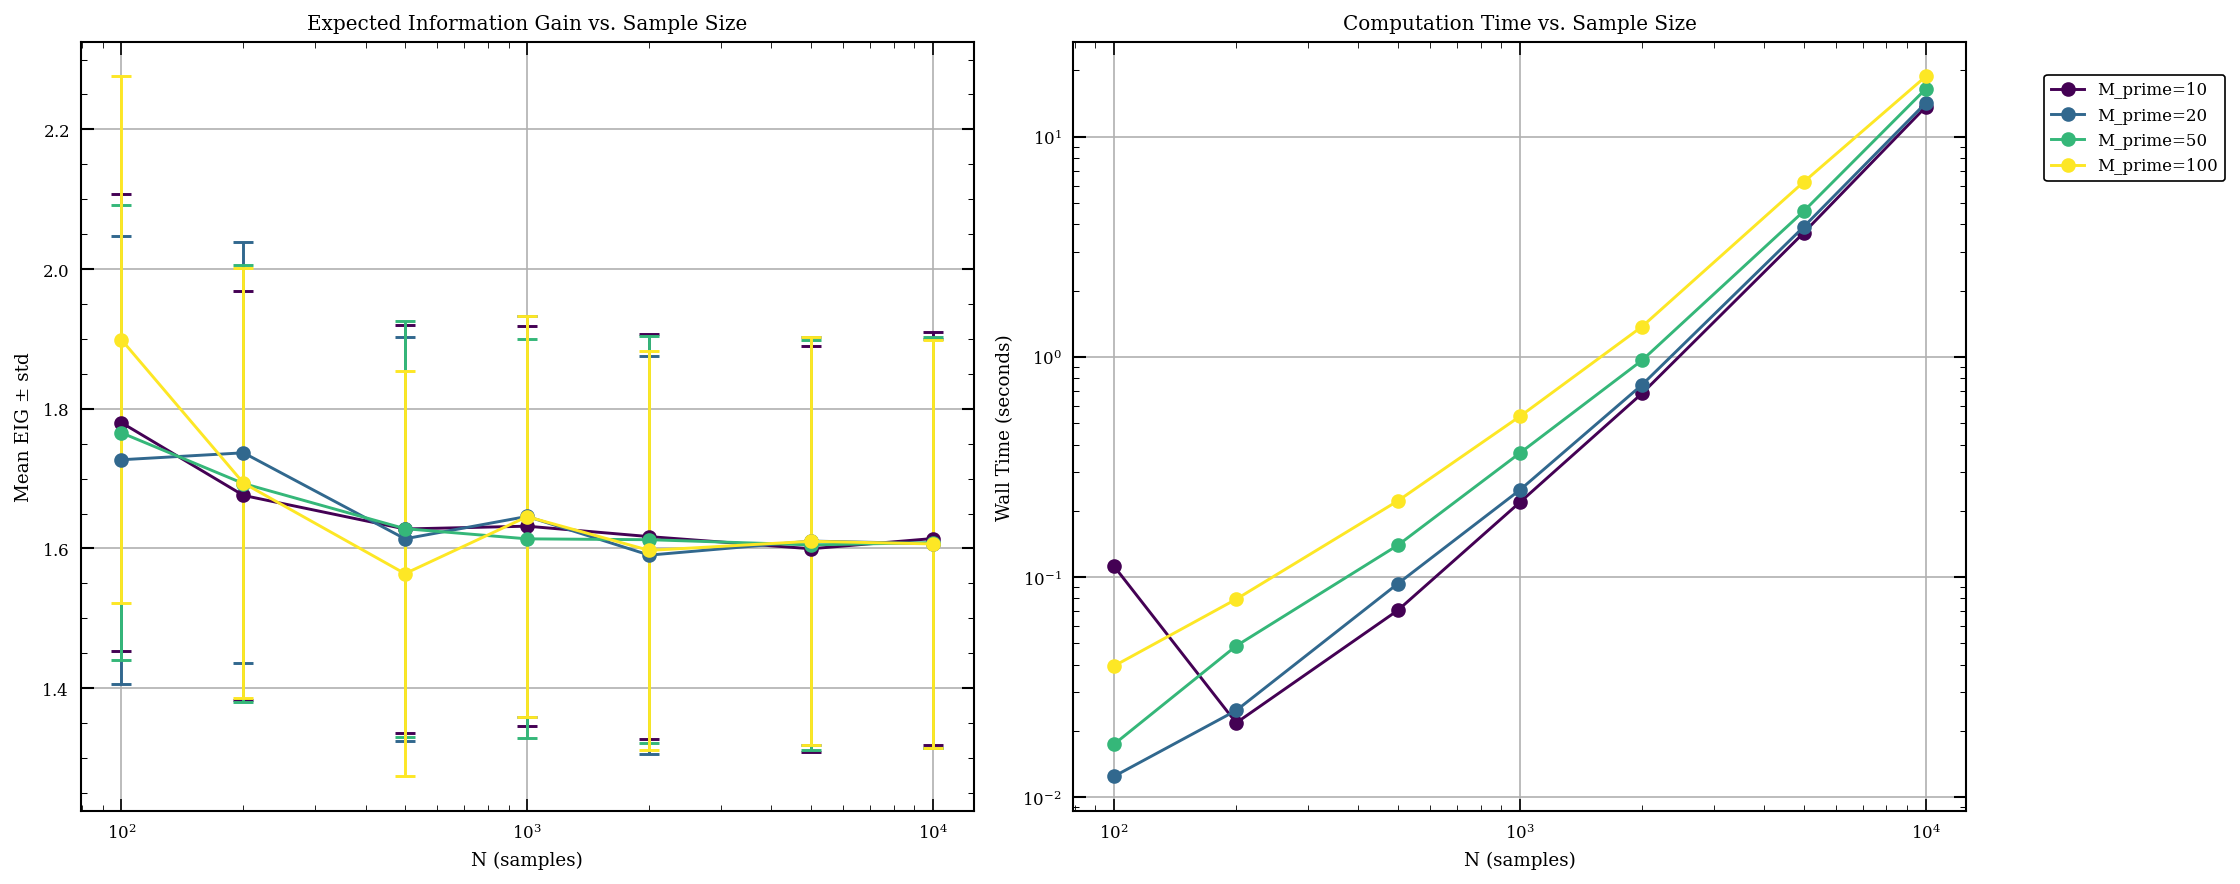

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

colors = plt.cm.viridis(np.linspace(0, 1, len(M_prime_scenarios)))
# First subplot (EIG) - reuse existing code
for M_prime in M_prime_scenarios:
    y_values = []
    yerr_values = []
    
    for N in N_scenarios:
        try:
            y_values.append(mean_EIG[(N, M_prime)])
            yerr_values.append(std_EIG[(N, M_prime)])
        except KeyError:
            y_values.append(np.nan)
            yerr_values.append(np.nan)
    
    ax1.errorbar(N_scenarios, y_values, yerr=yerr_values, fmt='o-', 
                label=f'M_prime={M_prime}', capsize=5,
                color=colors[M_prime_scenarios.index(M_prime)])

# Second subplot (Wall Time)
for M_prime in M_prime_scenarios:
    wall_times = []
    
    for N in N_scenarios:
        try:
            # Calculate mean wall time for this N, M_prime combination
            times = [info['wall_time'] for info in info_dict[(N, M_prime)]]
            wall_times.append(np.mean(times))
        except KeyError:
            wall_times.append(np.nan)
    
    ax2.plot(N_scenarios, wall_times, 'o-', 
             label=f'M_prime={M_prime}',
             color=colors[M_prime_scenarios.index(M_prime)])

# Configure first subplot
ax1.set_xscale('log')
ax1.set_xlabel('N (samples)')
ax1.set_ylabel('Mean EIG ± std')
ax1.set_title('Expected Information Gain vs. Sample Size')
ax1.grid(True)

# Configure second subplot
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('N (samples)')
ax2.set_ylabel('Wall Time (seconds)')
ax2.set_title('Computation Time vs. Sample Size')
ax2.grid(True)

# Add legend to the rightmost subplot
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

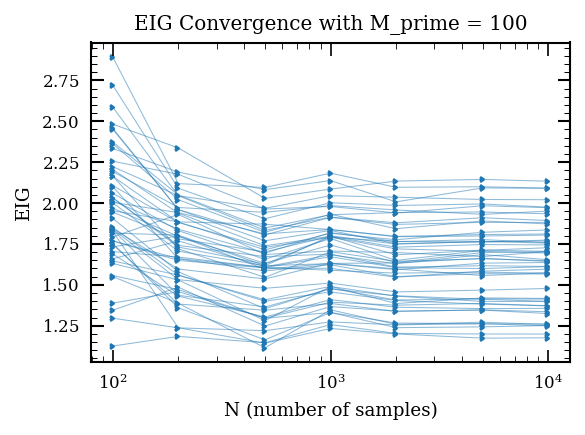

In [7]:
M_prime = 100
N_designs_plot = 50

# Create a figure with a single axis
fig, ax = plt.subplots(figsize=(4, 3))


# Plot individual design trajectories with low opacity
for design_idx in range(len(designs[:N_designs_plot])):
    eig_values = [EIG_dict[(N, M_prime)][design_idx].item() for N in N_scenarios]
    ax.plot(N_scenarios, eig_values, color='tab:blue', linestyle='-', linewidth=0.5, alpha=0.5)
    ax.scatter(N_scenarios, eig_values, color='tab:blue', s=5, marker=5)

# Set log scale for x-axis
ax.set_xscale('log')

# Add labels and title
ax.set_xlabel('N (number of samples)')
ax.set_ylabel('EIG')
ax.set_title(f'EIG Convergence with M_prime = {M_prime}')


plt.tight_layout()
plt.show()

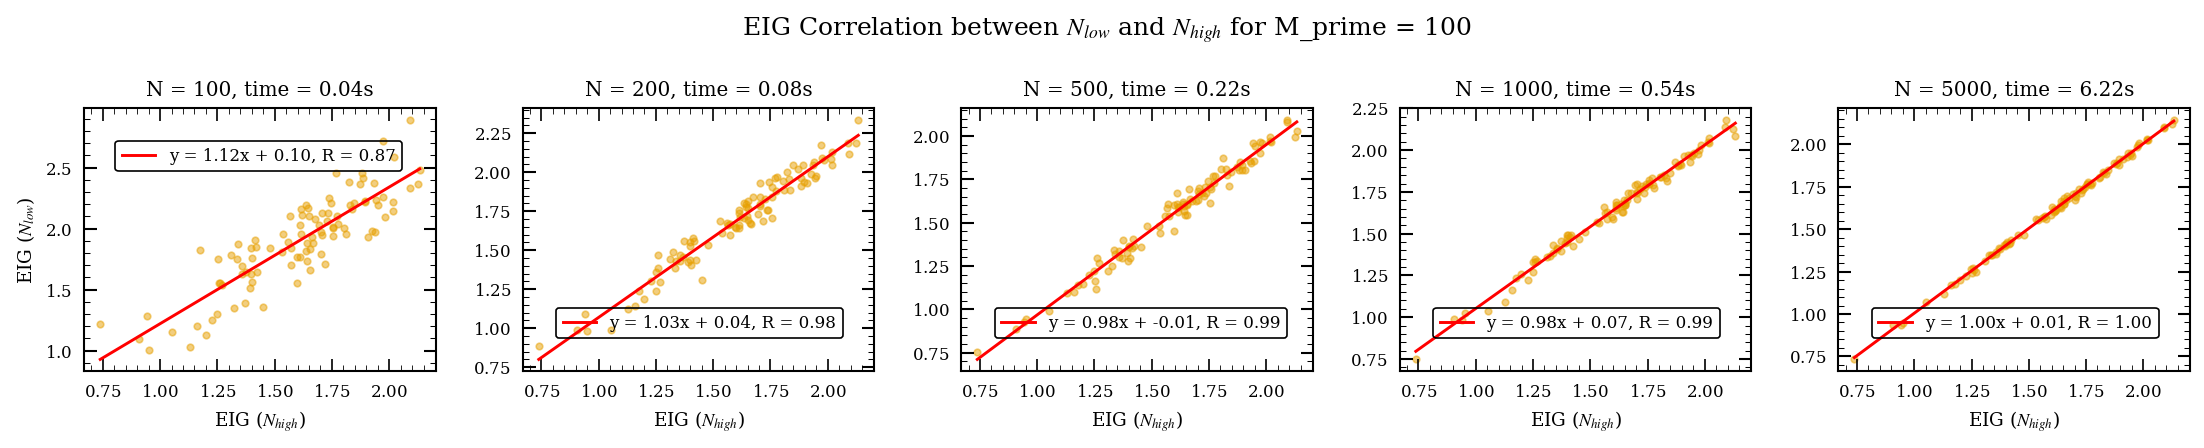

In [8]:
from scipy.stats import pearsonr

N_plot = [100, 200, 500, 1000, 5000]
M_prime = 100

fig, axs = plt.subplots(
    1, len(N_plot),
    figsize=(3 * (len(N_plot)), 3))

axs = axs.ravel()

for i, N_low in enumerate(N_plot):
    # Get EIGs for N_low and N_high
    N_high = N_scenarios[-1]
    
    # Get EIG data for both N values from EIG_dict
    eig_low = EIG_dict[(N_low, M_prime_scenarios[-1])]
    eig_high = EIG_dict[(N_high, M_prime_scenarios[-1])]
    
    # Fit line
    slope, intercept = np.polyfit(eig_high, eig_low, 1)
    line_x = np.array([eig_high.min(), eig_high.max()])
    line_y = slope * line_x + intercept
    
    # Calculate Pearson correlation coefficient
    r_value, _ = pearsonr(eig_high.numpy(), eig_low.numpy())
    
    # Plot
    axs[i].scatter(eig_high, eig_low, alpha=0.5, s=10)
    axs[i].plot(line_x, line_y, 'r-', label=f'y = {slope:.2f}x + {intercept:.2f}, R = {r_value:.2f}')
    axs[i].set_xlabel(f'EIG ($N_{{high}}$)')
    if i == 0:
        axs[i].set_ylabel(f'EIG ($N_{{low}}$)')
        
    wall_time = np.mean([info['wall_time'] for info in info_dict[(N_low, M_prime_scenarios[-1])]])
        
    axs[i].set_title(f'N = {N_low}, time = {wall_time:.2f}s')
    
    axs[i].legend()
    
fig.suptitle(f'EIG Correlation between $N_{{low}}$ and $N_{{high}}$ for M_prime = {M_prime_scenarios[-1]}')

plt.tight_layout()    
plt.show()

In [9]:
# fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# N_designs = 10

# # Get the EIG values for (464, 5)
# eig_values = EIG_dict[(2154, 20)][:N_designs]  # taking first 20 designs
# designs_to_plot = designs[:N_designs]

# colors = plt.cm.viridis((eig_values - eig_values.min()) / (eig_values.max() - eig_values.min()))

# # Create scatter plot for each receiver in the designs
# for i in range(N_designs):
#     ax.scatter(
#         designs_to_plot[i][:, 0], designs_to_plot[i][:, 1],
#         color=colors[i], s=50, marker='^', label=f'Design {i + 1}',
#         alpha=(eig_values[i].item() - eig_values.min().item()) / (eig_values.max().item() - eig_values.min().item())
#     )
#     ax.plot(
#         designs_to_plot[i][:, 0].tolist() + [designs_to_plot[i][0, 0].item()],
#         designs_to_plot[i][:, 1].tolist() + [designs_to_plot[i][0, 1].item()],
#         color=colors[i], marker=None, linestyle='--', linewidth=1,
#         alpha=(eig_values[i].item() - eig_values.min().item()) / (eig_values.max().item() - eig_values.min().item())
#     )
# # Add colorbar
# fig.colorbar(
#     plt.cm.ScalarMappable(
#         cmap='viridis', 
#         norm=plt.Normalize(vmin=eig_values.min().item(),
#                            vmax=eig_values.max().item())),
#     ax=ax, label='EIG')

# ax.set_xlabel('X coordinate')
# ax.set_ylabel('Y coordinate')
# ax.set_aspect('equal')
# ax.set_title('First 20 Designs Colored by EIG')
# ax.grid(True)

# DN Method

In [10]:
EIG_dict_DN = {}
info_dict_DN = {}

for N in N_scenarios:
    N = N.item() if isinstance(N, torch.Tensor) else N
    for M_prime in M_prime_scenarios:
        
        print(f'Calculating EIG for N = {N} and M_prime = {M_prime}')
        
        eig, info = BED_class.calculate_EIG(
            designs,
            eig_method='DN',
            eig_method_kwargs=dict(
                N = N,
                M_prime = M_prime),
            num_workers=n_workers,
            random_seed=0,
            progress_bar=True,
            parallel_library='mpire',
            filename=f'convergence_analysis/data/EIG_DN_attenuation_{N}_M_{M_prime}.pt',
            )
            
        EIG_dict_DN[(N, M_prime)] = eig
        info_dict_DN[(N, M_prime)] = info

Calculating EIG for N = 100 and M_prime = 10


Calculating eig:   0%|          | 0/100 [00:00<?, ?it/s]

Calculating EIG for N = 100 and M_prime = 20


Calculating eig:   0%|          | 0/100 [00:00<?, ?it/s]

Calculating EIG for N = 100 and M_prime = 50


...

Calculating eig:   0%|          | 0/100 [00:00<?, ?it/s]

Calculating EIG for N = 10000 and M_prime = 50


Calculating eig:   0%|          | 0/100 [00:00<?, ?it/s]

Calculating EIG for N = 10000 and M_prime = 100


Calculating eig:   0%|          | 0/100 [00:00<?, ?it/s]

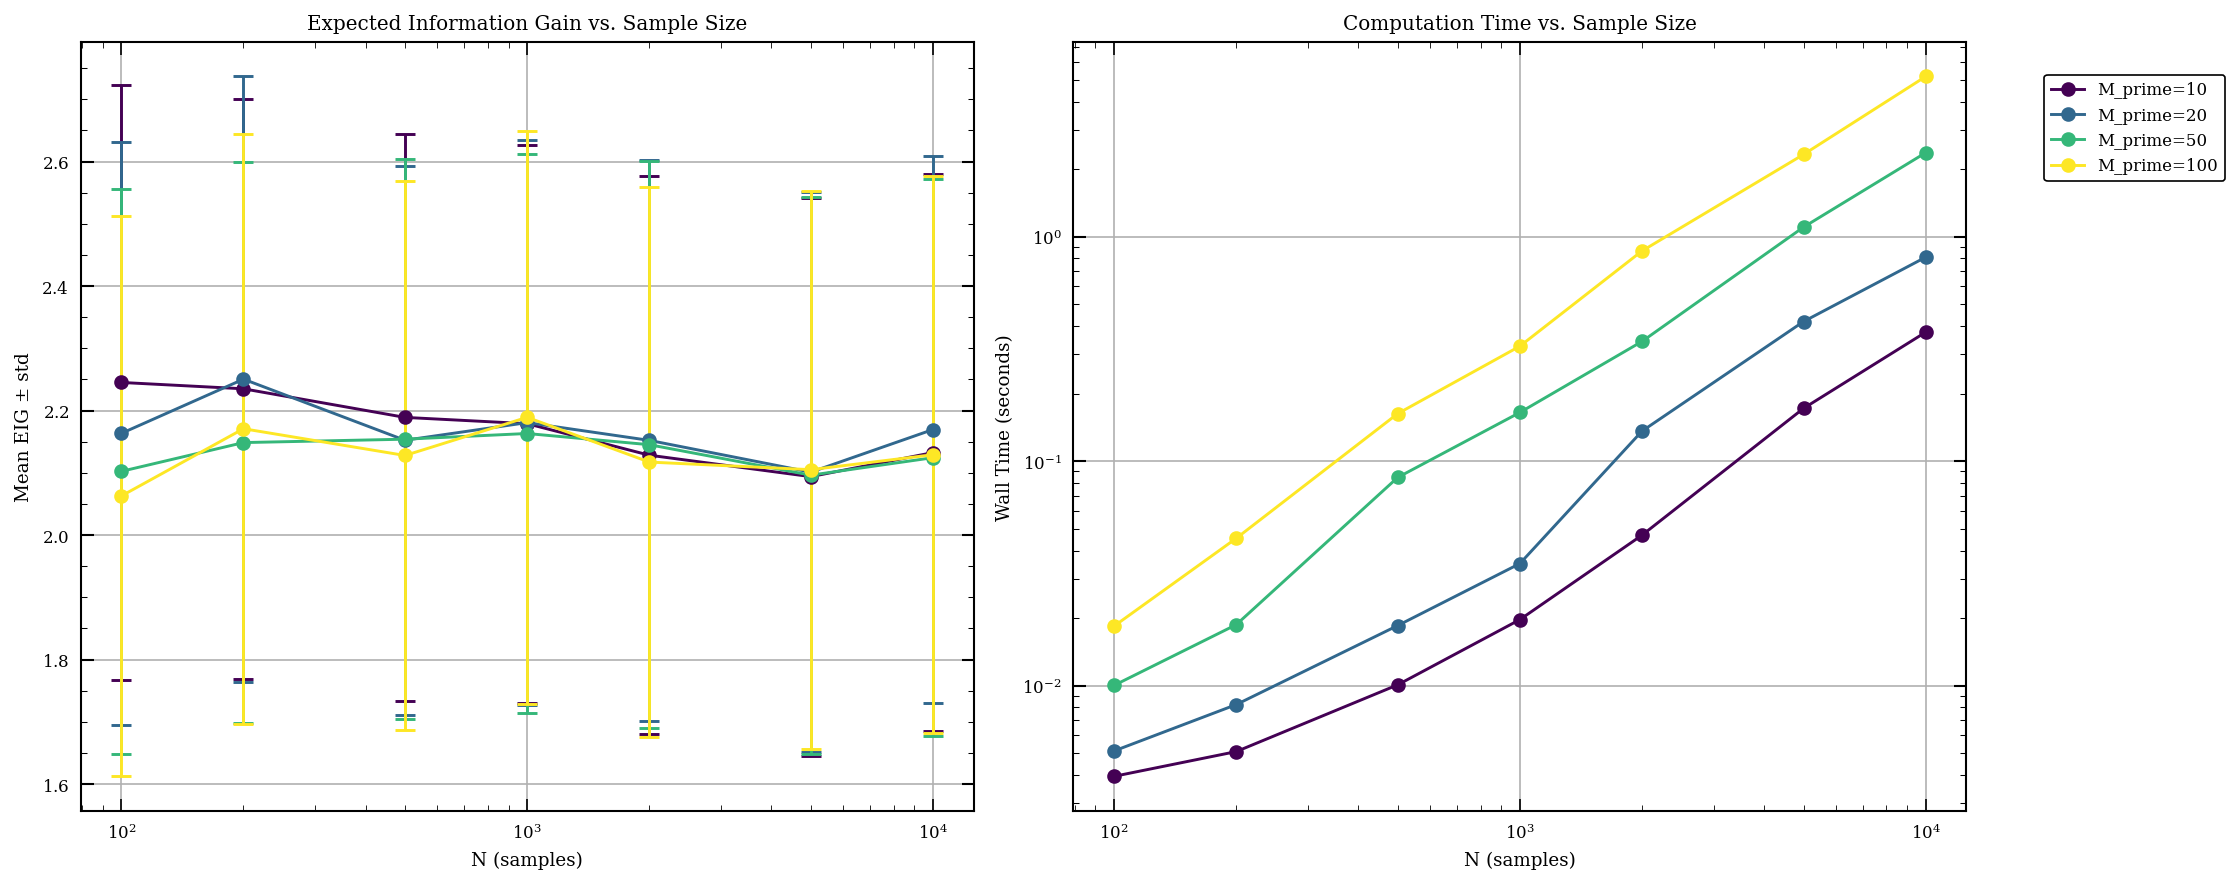

In [11]:
mean_EIG_DN = {
    key: eig.mean(dim=0).item() for key, eig in EIG_dict_DN.items()
}
std_EIG_DN = {
    key: eig.std(dim=0).item() for key, eig in EIG_dict_DN.items()
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

colors = plt.cm.viridis(np.linspace(0, 1, len(M_prime_scenarios)))
# First subplot (EIG) - reuse existing code
for M_prime in M_prime_scenarios:
    y_values = []
    yerr_values = []
    
    for N in N_scenarios:
        try:
            y_values.append(mean_EIG_DN[(N, M_prime)])
            yerr_values.append(std_EIG_DN[(N, M_prime)])
        except KeyError:
            y_values.append(np.nan)
            yerr_values.append(np.nan)
    
    ax1.errorbar(N_scenarios, y_values, yerr=yerr_values, fmt='o-', 
                label=f'M_prime={M_prime}', capsize=5,
                color=colors[M_prime_scenarios.index(M_prime)])

# Second subplot (Wall Time)
for M_prime in M_prime_scenarios:
    wall_times = []
    
    for N in N_scenarios:
        try:
            # Calculate mean wall time for this N, M_prime combination
            times = [info['wall_time'] for info in info_dict_DN[(N, M_prime)]]
            wall_times.append(np.mean(times))
        except KeyError:
            wall_times.append(np.nan)
    
    ax2.plot(N_scenarios, wall_times, 'o-', 
             label=f'M_prime={M_prime}',
             color=colors[M_prime_scenarios.index(M_prime)])

# Configure first subplot
ax1.set_xscale('log')
ax1.set_xlabel('N (samples)')
ax1.set_ylabel('Mean EIG ± std')
ax1.set_title('Expected Information Gain vs. Sample Size')
ax1.grid(True)

# Configure second subplot
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('N (samples)')
ax2.set_ylabel('Wall Time (seconds)')
ax2.set_title('Computation Time vs. Sample Size')
ax2.grid(True)

# Add legend to the rightmost subplot
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

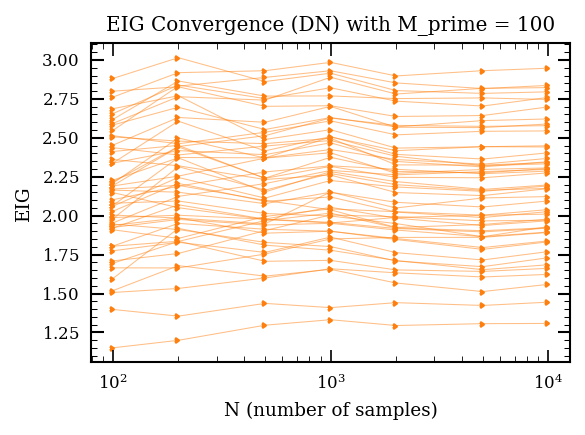

In [12]:
M_prime = 100
N_designs_plot = 50

# Create a figure with a single axis
fig, ax = plt.subplots(figsize=(4, 3))


# Plot individual design trajectories with low opacity
for design_idx in range(len(designs[:N_designs_plot])):
    eig_values = [EIG_dict_DN[(N, M_prime_scenarios[-1])][design_idx].item() for N in N_scenarios]
    ax.plot(N_scenarios, eig_values, color='tab:orange', linestyle='-', linewidth=0.5, alpha=0.5)
    ax.scatter(N_scenarios, eig_values, color='tab:orange', s=5, marker=5)

# Set log scale for x-axis
ax.set_xscale('log')

# Add labels and title
ax.set_xlabel('N (number of samples)')
ax.set_ylabel('EIG')
ax.set_title(f'EIG Convergence (DN) with M_prime = {M_prime_scenarios[-1]}')


plt.tight_layout()
plt.show()

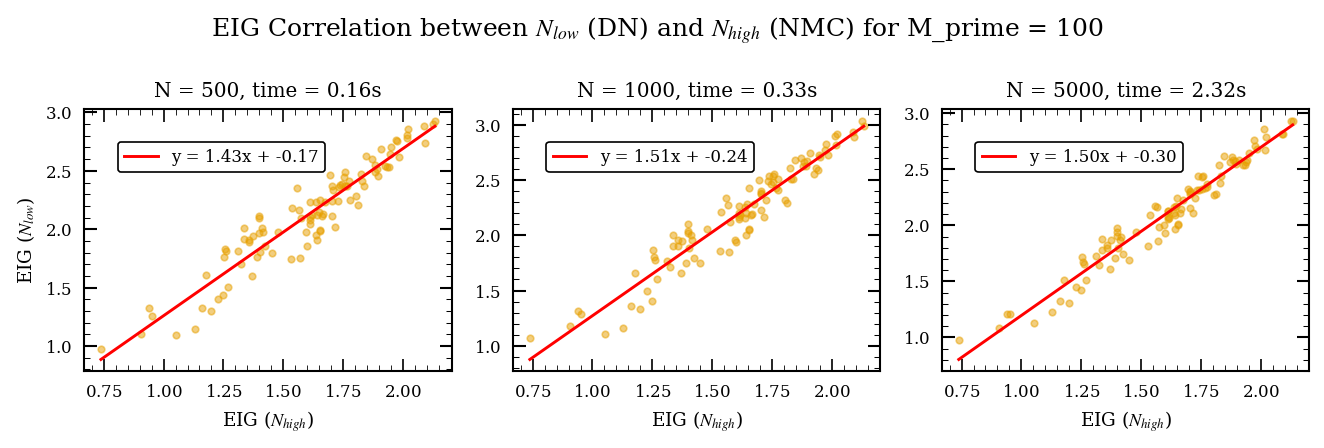

In [13]:
N_plot = [500, 1000, 5000]
M_prime = 100

fig, axs = plt.subplots(
    1, len(N_plot),
    figsize=(3 * (len(N_plot)), 3))

axs = axs.ravel()

for i, N_low in enumerate(N_plot):
    # Get EIGs for N_low and N_high
    N_high = N_scenarios[-1]
    
    # Get EIG data for both N values from EIG_dict
    eig_low = EIG_dict_DN[(N_low, M_prime_scenarios[-1])]
    eig_high = EIG_dict[(N_high, M_prime_scenarios[-1])]
    
    # Fit line
    slope, intercept = np.polyfit(eig_high, eig_low, 1)  # Swapped order here
    line_x = np.array([eig_high.min(), eig_high.max()])
    line_y = slope * line_x + intercept
    
    # Plot
    axs[i].scatter(eig_high, eig_low, alpha=0.5, s=10)  # Swapped order here
    axs[i].plot(line_x, line_y, 'r-', label=f'y = {slope:.2f}x + {intercept:.2f}')
    axs[i].set_xlabel(f'EIG ($N_{{high}}$)')  # Swapped labels
    if i == 0:
        axs[i].set_ylabel(f'EIG ($N_{{low}}$)')
        
    wall_time = np.mean([info['wall_time'] for info in info_dict_DN[(N_low, M_prime_scenarios[-1])]])
        
    axs[i].set_title(f'N = {N_low}, time = {wall_time:.2f}s')
    
    axs[i].legend()
    
fig.suptitle(f'EIG Correlation between $N_{{low}}$ (DN) and $N_{{high}}$ (NMC) for M_prime = {M_prime_scenarios[-1]}')

plt.tight_layout()    
plt.show()